> Learn how to select the best forecasting models when you care about more than one metric — without manually ranking and comparing every combination.

## What you'll learn

- Why single-metric model selection can be misleading
- What Pareto dominance means and when a model is "dominated"
- How to use `evaluate()` correctly as input to `ParetoFrontier`
- How to visualize the 2D Pareto frontier across any two metrics
- How to handle cross-validation output for multi-objective selection

## The problem: picking one winner across multiple metrics

After training several forecasting models, a common question is: **which one should I deploy?**

If you optimize for a single metric — say MAE — the answer is straightforward: pick the lowest MAE. But real-world requirements rarely reduce to a single number. You might care about:

- **Accuracy** (MAE, RMSE): how close are point forecasts to actuals?
- **Relative error** (MAPE, sMAPE): how large is the error relative to the scale of the series?
- **Bias** (bias, CFE): does the model systematically over- or under-forecast?

When metrics disagree — Model A has the best MAE, Model B has the best MAPE — a simple ranking breaks down.

**Pareto analysis** offers a principled solution: instead of collapsing everything to a single score, identify which models are not *dominated*. A model is dominated when another model is at least as good on every metric and strictly better on at least one. Non-dominated models form the **Pareto frontier** — the set of trade-off-optimal choices.

## Install libraries

In [1]:
%%capture
pip install utilsforecast statsforecast -U

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, MSTL, SeasonalNaive

from utilsforecast.data import generate_series
from utilsforecast.losses import mae, mape, rmse, smape
from utilsforecast.evaluation import evaluate
from utilsforecast.model_selection import ParetoFrontier

## Generate synthetic time series

We use `generate_series` to create a panel of daily time series with weekly seasonality. Each series contains between 100 and 150 observations, giving models enough history for a meaningful fit.

In [3]:
series = generate_series(
    n_series=8,
    freq='D',
    min_length=100,
    max_length=150,
    seed=42,
)
# StatsForecast requires string or integer unique_id, not Categorical
series['unique_id'] = series['unique_id'].astype(str)
series.head()

,unique_id,ds,y
0,0,2000-01-01,0.049987
1,0,2000-01-02,1.229624
2,0,2000-01-03,2.166854
3,0,2000-01-04,3.071433
4,0,2000-01-05,4.325444


We hold out the last 14 days of each series as the evaluation window and use the rest for training.

In [4]:
HORIZON = 14
SEASON  = 7

test_mask = series.groupby('unique_id').cumcount(ascending=False) < HORIZON
train = series[~test_mask].reset_index(drop=True)
test  = series[test_mask].reset_index(drop=True)

print(f'Train: {len(train)} rows | Test: {len(test)} rows')

Train: 893 rows | Test: 112 rows


## Fit models and generate forecasts

We compare three models that cover a range of complexity:

- **SeasonalNaive** — repeats the last observed season. Fast, transparent, surprisingly hard to beat.
- **AutoARIMA** — fits a SARIMA model selected automatically by AIC. More flexible but slower.
- **MSTL** — decomposes the series into trend and seasonal components using STL, then forecasts each part separately. Good at capturing multiple seasonal patterns.

In [5]:
sf = StatsForecast(
    models=[
        SeasonalNaive(season_length=SEASON),
        AutoARIMA(season_length=SEASON),
        MSTL(season_length=SEASON),
    ],
    freq='D',
    n_jobs=1,
)
sf.fit(train)
preds = sf.predict(h=HORIZON)
preds.head()

,unique_id,ds,SeasonalNaive,AutoARIMA,MSTL
0,0,2000-05-04,5.453414,5.296218,5.283464
1,0,2000-05-05,6.136066,6.198051,6.193499
2,0,2000-05-06,0.323845,0.277377,0.280454
3,0,2000-05-07,1.000260,1.234950,1.244538
4,0,2000-05-08,2.176284,2.252924,2.278188


Merge predictions with the held-out actuals to get a single DataFrame ready for `evaluate()`.

In [6]:
eval_df = test.merge(preds, on=['unique_id', 'ds'], how='left')
eval_df.head()

,unique_id,ds,y,SeasonalNaive,AutoARIMA,MSTL
0,0,2000-05-04,5.267045,5.453414,5.296218,5.283464
1,0,2000-05-05,6.242415,6.136066,6.198051,6.193499
2,0,2000-05-06,0.346218,0.323845,0.277377,0.280454
3,0,2000-05-07,1.134706,1.000260,1.234950,1.244538
4,0,2000-05-08,2.122063,2.176284,2.252924,2.278188


## Evaluate models across multiple metrics

`evaluate()` computes any combination of loss functions from `utilsforecast.losses` and returns a tidy DataFrame with one row per `(unique_id, metric)` and one column per model.

For Pareto analysis we need **one scalar per metric per model** — a single number that summarises performance across all series. The `agg_fn='mean'` argument collapses the per-series rows into a single mean, giving a `(n_metrics, n_models)` table.

In [7]:
scores = evaluate(
    df=eval_df,
    metrics=[mae, rmse, mape, smape],
    agg_fn='mean',
)
scores

,metric,SeasonalNaive,AutoARIMA,MSTL
0,mae,0.162020,0.120070,0.119955
1,rmse,0.196461,0.145129,0.144143
2,mape,0.354416,0.359234,0.340032
3,smape,0.087060,0.065840,0.064982


At a glance, no single model wins on every metric. MSTL tends to have lower absolute errors while SeasonalNaive can be competitive on relative metrics for series with strong weekly patterns. This is exactly the situation where Pareto analysis adds value.

## Find the Pareto frontier

`ParetoFrontier.find_non_dominated()` takes the aggregated scores table and returns only the columns corresponding to non-dominated models — dropping any model for which another model is at least as good on every metric and strictly better on at least one.

In [8]:
pareto = ParetoFrontier.find_non_dominated(scores)
pareto

,metric,MSTL
0,mae,0.119955
1,rmse,0.144143
2,mape,0.340032
3,smape,0.064982


The models that survive are the **Pareto-optimal** set. Dropping the rest is safe: for every eliminated model, there is at least one surviving model that dominates it across every metric simultaneously.

### Focusing on a subset of metrics

You can restrict the comparison to only the metrics that matter for your use case by passing a `metrics` list.

In [9]:
# Only consider MAE and RMSE for dominance — ignore MAPE and sMAPE
pareto_subset = ParetoFrontier.find_non_dominated(scores, metrics=['mae', 'rmse'])
pareto_subset

,metric,MSTL
0,mae,0.119955
1,rmse,0.144143


### Maximization metrics

By default all metrics are minimized (lower is better). If a metric should be maximized — for example, a custom R² score — pass its name in `maximization`.

In [10]:
# Hypothetical: minimize MAE but maximize some score column
# ParetoFrontier.find_non_dominated(scores, maximization=['score'])

# With the current metrics, this is equivalent to the default:
pareto_min = ParetoFrontier.find_non_dominated(scores, metrics=['mae', 'rmse', 'mape', 'smape'])
pareto_min

,metric,MSTL
0,mae,0.119955
1,rmse,0.144143
2,mape,0.340032
3,smape,0.064982


## Visualize the 2D Pareto frontier

When comparing two metrics, `ParetoFrontier.plot_pareto_2d()` renders a scatter plot where dominated models appear in grey and Pareto-optimal models appear in red, connected by a dashed frontier line.

<Axes: title={'center': 'MAE vs MAPE — Pareto Frontier'}, xlabel='mae', ylabel='mape'>

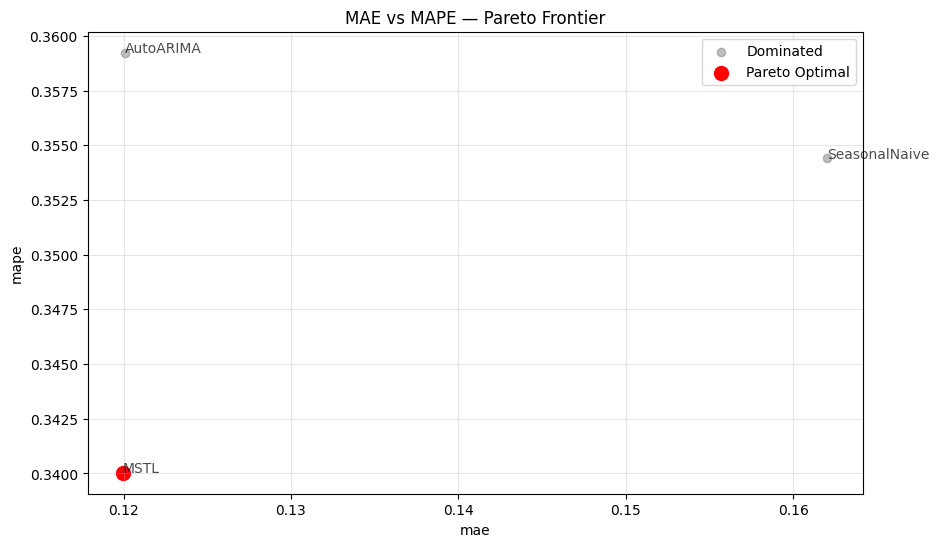

In [11]:
ParetoFrontier.plot_pareto_2d(
    scores,
    metric_x='mae',
    metric_y='mape',
    title='MAE vs MAPE — Pareto Frontier',
)

The plot accepts `maximize_x` and `maximize_y` flags for metrics where larger is better, and `show_dominated=False` to declutter the chart when many models are present.

## Cross-validation: multi-window model selection

A single held-out window can be noisy. StatsForecast's `cross_validation()` produces estimates across multiple windows, giving a more robust picture of model performance.

The cross-validation output has a `cutoff` column — `evaluate()` keeps it, so `agg_fn='mean'` aggregates across series *within each cutoff*, not across all windows at once. To collapse everything into a single row per metric for Pareto analysis, apply a second groupby.

In [12]:
cv = sf.cross_validation(df=series, h=HORIZON, n_windows=3)
cv['unique_id'] = cv['unique_id'].astype(str)
cv.head()

,unique_id,ds,cutoff,y,SeasonalNaive,AutoARIMA,MSTL
0,0,2000-05-02,2000-05-01,3.152391,3.061044,3.200568,3.200882
1,0,2000-05-03,2000-05-01,4.082328,4.178149,4.194904,4.197371
2,0,2000-05-04,2000-05-01,5.267045,5.453414,5.294926,5.284707
3,0,2000-05-05,2000-05-01,6.242415,6.136066,6.198686,6.194711
4,0,2000-05-06,2000-05-01,0.346218,0.323845,0.277010,0.282018


In [13]:
MODELS = [c for c in cv.columns if c not in {'unique_id', 'ds', 'cutoff', 'y'}]

# Step 1: compute per-(series, cutoff) scores
cv_scores = evaluate(
    df=cv,
    metrics=[mae, rmse, mape, smape],
)

# Step 2: average across both series and cutoffs
cv_scores_agg = cv_scores.groupby('metric', sort=False)[MODELS].mean().reset_index()
cv_scores_agg

,metric,SeasonalNaive,AutoARIMA,MSTL
0,mae,0.163304,0.119660,0.119076
1,rmse,0.196949,0.144753,0.143648
2,mape,0.349638,0.326070,0.317805
3,smape,0.086262,0.064798,0.063181


In [14]:
pareto_cv = ParetoFrontier.find_non_dominated(cv_scores_agg)
pareto_cv

,metric,MSTL
0,mae,0.119076
1,rmse,0.143648
2,mape,0.317805
3,smape,0.063181


<Axes: title={'center': 'MAE vs MAPE — Cross-Validated Pareto Frontier'}, xlabel='mae', ylabel='mape'>

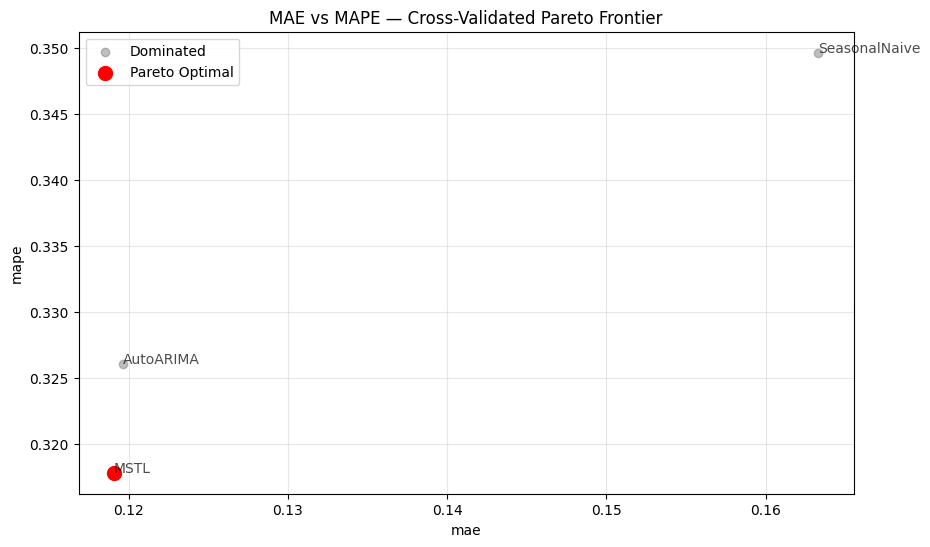

In [15]:
ParetoFrontier.plot_pareto_2d(
    cv_scores_agg,
    metric_x='mae',
    metric_y='mape',
    title='MAE vs MAPE — Cross-Validated Pareto Frontier',
)

## Custom column names

If your pipeline uses column names different from the defaults (`unique_id`, `cutoff`), pass `id_col` and `cutoff_col` to both `evaluate()` and `find_non_dominated()` so the Pareto analysis correctly identifies which columns are model predictions.

In [16]:
# Rename to simulate a custom pipeline
eval_df_custom = eval_df.rename(columns={'unique_id': 'series_id'})

scores_custom = evaluate(
    df=eval_df_custom,
    metrics=[mae, rmse],
    id_col='series_id',
    agg_fn='mean',
)

# Pass the same id_col so find_non_dominated() excludes it from model columns
ParetoFrontier.find_non_dominated(scores_custom, id_col='series_id')

,metric,MSTL
0,mae,0.119955
1,rmse,0.144143


## Key takeaways

- **Single-metric selection discards information.** When metrics disagree, there is no universally correct answer — only trade-offs worth making explicit.
- **Pareto dominance is a lossless filter.** Every eliminated model is objectively outperformed; no information about the surviving frontier is lost.
- **Always aggregate before calling `find_non_dominated()`.** Pass `agg_fn='mean'` to `evaluate()` so the input has exactly one row per metric. For cross-validation output, apply a second groupby over the `metric` column to collapse across cutoffs as well.
- **`plot_pareto_2d()` makes the trade-off tangible.** Pick any two metrics on the axes to see which models sit on the frontier and which ones are dominated.
- **Custom column names are supported.** Pass `id_col` and `cutoff_col` consistently across `evaluate()` and `find_non_dominated()` when your data uses non-default names.